In [1]:
import sys
from pathlib import Path

# Adding project root to sys.path 
root = Path().resolve().parent 
sys.path.append(str(root))

from config import RAW_DIR, INTERIM_DIR
import pandas as pd

print("RAW_DIR:", RAW_DIR)
print("INTERIM_DIR:", INTERIM_DIR)


RAW_DIR: C:\DataProjects\uh-ds-housing-data\data\raw
INTERIM_DIR: C:\DataProjects\uh-ds-housing-data\data\interim


Loaded 5,944,841 rows and 14 columns
Using sample: 50,000 rows
Features used: ['year', 'month', 'property_type', 'county', 'district', 'town_city']
Train: (40000, 6), Test: (10000, 6)
Numeric: ['year', 'month']
Categorical: ['property_type', 'county', 'district', 'town_city']
Training Random Forest Regressor...
Model training complete.


C:\Users\BALA\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(



 Evaluation Metrics:
MAE : 0.346
RMSE: 0.485
R²  : 0.495


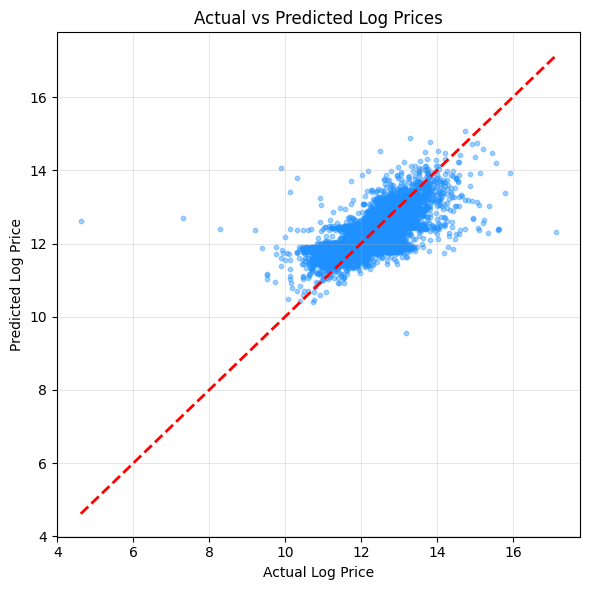

In [3]:
# === 05_RandomForestRegressor_model.ipynb ===
# (Regression: Predict Log House Price)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from config import PROCESSED_DIR

# 1️ Load processed dataset
data_path = PROCESSED_DIR / "uk_housing_2010_2017_processed.csv"
df = pd.read_csv(data_path, low_memory=False)
print(f"Loaded {len(df):,} rows and {df.shape[1]} columns")

# 2️ Sample subset for faster demo/training
df_sample = df.sample(50_000, random_state=42).copy()
print(f"Using sample: {len(df_sample):,} rows")

# 3️ Define features and target
possible_features = [
    "year", "month", "property_type", "new_build_flag", "tenure_type",
    "county", "district", "local_authority", "town_city"
]
features = [f for f in possible_features if f in df_sample.columns]
target = "log_price"

if target not in df_sample.columns:
    raise KeyError(f"Target column '{target}' not found!")

print("Features used:", features)

X = df_sample[features]
y = df_sample[target]

# 4️ Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

# 5️ Identify numeric vs categorical features
num_features = [f for f in ["year", "month"] if f in X_train.columns]
cat_features = [f for f in X_train.columns if f not in num_features]
print("Numeric:", num_features)
print("Categorical:", cat_features)

# 6️ Preprocessing pipelines
num_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler())
])

cat_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("encode", OneHotEncoder(handle_unknown="ignore", sparse_output=True))
])

preprocessor = ColumnTransformer([
    ("num", num_pipe, num_features),
    ("cat", cat_pipe, cat_features)
])

# 7️ Model pipeline (Random Forest)
model = Pipeline([
    ("prep", preprocessor),
    ("rf", RandomForestRegressor(
        n_estimators=200,
        max_depth=20,
        n_jobs=-1,
        random_state=42
    ))
])

print("Training Random Forest Regressor...")
model.fit(X_train, y_train)
print("Model training complete.")

# 8️ Evaluate model
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred, squared=False)
r2 = r2_score(y_test, y_pred)

print("\n Evaluation Metrics:")
print(f"MAE : {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R²  : {r2:.3f}")

# 9️ Visualize Actual vs Predicted
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.4, s=10, color="dodgerblue")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", lw=2)
plt.title("Actual vs Predicted Log Prices")
plt.xlabel("Actual Log Price")
plt.ylabel("Predicted Log Price")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
